# ER Wait Time Dataset - 기초 EDA

데이터 출처: `ER Wait Time Dataset.csv` (5,000건의 시뮬레이션된 응급실 방문 데이터)

In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\yeonw\OneDrive\Desktop\ER\ER Wait Time Dataset.csv")
df = pd.read_csv(DATA_PATH)

print(f"행: {df.shape[0]}, 열: {df.shape[1]}")

행: 5000, 열: 19


In [2]:
# 컬럼별 데이터 타입 및 결측 여부 개요
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Visit ID                            5000 non-null   str  
 1   Patient ID                          5000 non-null   str  
 2   Hospital ID                         5000 non-null   str  
 3   Hospital Name                       5000 non-null   str  
 4   Region                              5000 non-null   str  
 5   Visit Date                          5000 non-null   str  
 6   Day of Week                         5000 non-null   str  
 7   Season                              5000 non-null   str  
 8   Time of Day                         5000 non-null   str  
 9   Urgency Level                       5000 non-null   str  
 10  Nurse-to-Patient Ratio              5000 non-null   int64
 11  Specialist Availability             5000 non-null   int64
 12  Facility Size (Be

In [3]:
# 샘플 10개 확인
df.head(10)

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1
5,HOSP-5-20241120-0001,PAT-00006,HOSP-5,Summit Health Center,Urban,2024-11-20 22:34:08,Wednesday,Fall,Night,Medium,3,7,167,12,15,36,63,Discharged,3
6,HOSP-3-20240221-0003,PAT-00007,HOSP-3,Northside Community Hospital,Rural,2024-02-21 15:26:54,Wednesday,Winter,Late Morning,Medium,4,2,42,22,37,57,116,Admitted,1
7,HOSP-2-20241212-0002,PAT-00008,HOSP-2,Riverside Medical Center,Urban,2024-12-12 20:23:38,Thursday,Winter,Afternoon,Medium,3,2,84,8,25,48,81,Admitted,2
8,HOSP-1-20241129-0003,PAT-00009,HOSP-1,Springfield General Hospital,Urban,2024-11-29 02:47:33,Friday,Fall,Afternoon,Medium,4,3,87,16,27,35,78,Discharged,2
9,HOSP-1-20240727-0004,PAT-00010,HOSP-1,Springfield General Hospital,Urban,2024-07-27 22:01:14,Saturday,Summer,Afternoon,Critical,1,4,99,3,3,5,11,Admitted,5


In [4]:
# 결측치 확인
df.isnull().sum()

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

In [5]:
# 중복값 확인
print("전체 중복 행 수:", df.duplicated().sum())
print("Visit ID 기준 중복 수:", df.duplicated(subset=["Visit ID"]).sum())

전체 중복 행 수: 0
Visit ID 기준 중복 수: 0


## 타겟(클래스) 비율

이 데이터셋의 목적상 분류 타겟으로 삼기 적합한 컬럼은 `Patient Outcome`(Admitted / Discharged / Left Without Being Seen)이다.

In [6]:
# 타겟(Patient Outcome) 클래스 비율
target_counts = df["Patient Outcome"].value_counts()
target_ratio = df["Patient Outcome"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({"count": target_counts, "ratio(%)": target_ratio})

,count,ratio(%)
Patient Outcome,,
Discharged,2879,57.58
Admitted,1868,37.36
Left Without Being Seen,253,5.06


In [1]:
import matplotlib.pyplot as plt

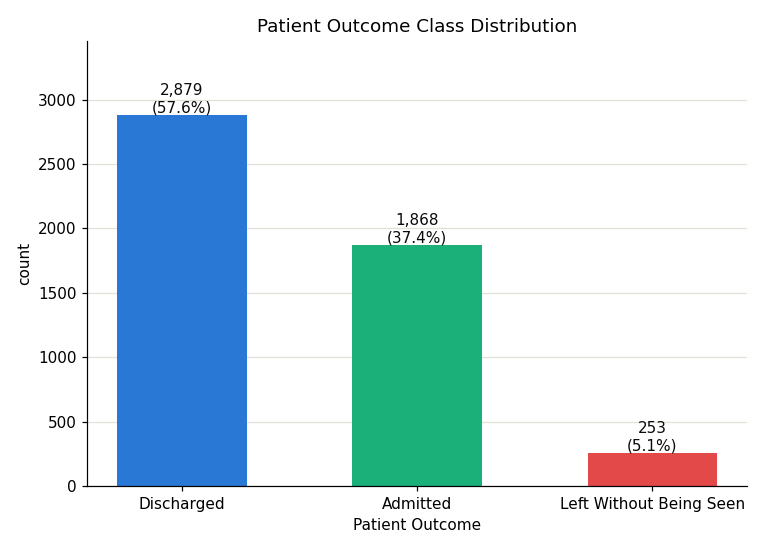

In [1]:
# 클래스 불균형 시각화 (Patient Outcome)
colors = ["#2a78d6", "#1baf7a", "#e34948"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_counts.index, target_counts.values, color=colors[:len(target_counts)], width=0.55)

for bar, cnt, pct in zip(bars, target_counts.values, target_ratio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, color="#0b0b0b")

ax.set_title("Patient Outcome Class Distribution")
ax.set_xlabel("Patient Outcome")
ax.set_ylabel("count")
ax.set_ylim(0, target_counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()